# AI- Driven FedEX Shipment Delay Predicition & Logistics Analytics

# Problem Statement

Fedex and logistics companies often face shipment delays, increasing freight costs, and operational inefficiencies.

This project analyzes shipment data and uses machine learning to predict delivery delays and improve logistics performance.

## Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/SCMS_Delivery_History_Dataset.csv')

In [ ]:
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


## Loading and Understanding Dataset

In [ ]:
df.shape

(10324, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

## Data Cleaning and Preprocessing



In [ ]:
df.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Shipment Mode,360
Dosage,1736
Line Item Insurance (USD),287


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
ID,0.000000
Project Code,0.000000
PQ #,0.000000
PO / SO #,0.000000
ASN/DN #,0.000000
Country,0.000000
Managed By,0.000000
Fulfill Via,0.000000
Vendor INCO Term,0.000000
Shipment Mode,3.487021


In [ ]:
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

## Date Conversion



In [ ]:
date_columns = [
    'PQ First Sent to Client Date',
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Recorded Date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

/tmp/ipykernel_1058/3855771012.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1058/3855771012.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1058/3855771012.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1058/3855771012.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consis

## Feature Engineering

In [ ]:
df['Delivery Delay Days'] = (
       df['Delivered to Client Date'] - df['Scheduled Delivery Date']
).dt.days

In [ ]:
df[['Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Delay Days']].head()

,Scheduled Delivery Date,Delivered to Client Date,Delivery Delay Days
0,2006-06-02,2006-06-02,0
1,2006-11-14,2006-11-14,0
2,2006-08-27,2006-08-27,0
3,2006-09-01,2006-09-01,0
4,2006-08-11,2006-08-11,0


In [ ]:
df['Delivery Status'] = df['Delivery Delay Days'].apply(
    lambda x: 'Delayed' if x > 0 else 'On Time'
)

## Exploratory Data Analysis (EDA)

In [ ]:
df['Delivery Status'].value_counts()

,count
Delivery Status,
On Time,9138
Delayed,1186


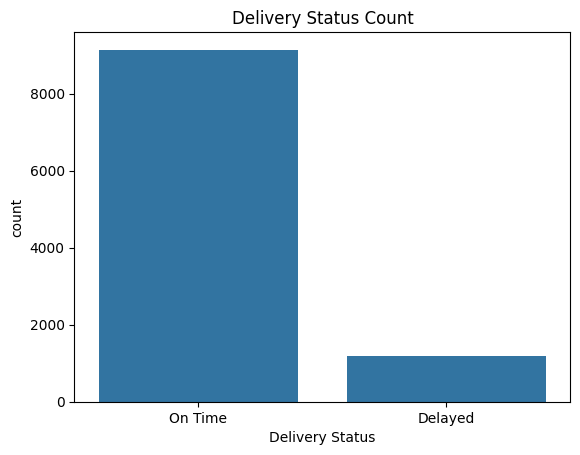

In [ ]:
sns.countplot(x='Delivery Status', data=df)
plt.title('Delivery Status Count')
plt.show()

In [ ]:
df['Shipment Mode'].value_counts()

,count
Shipment Mode,
Air,6113
Truck,2830
Air Charter,650
Ocean,371


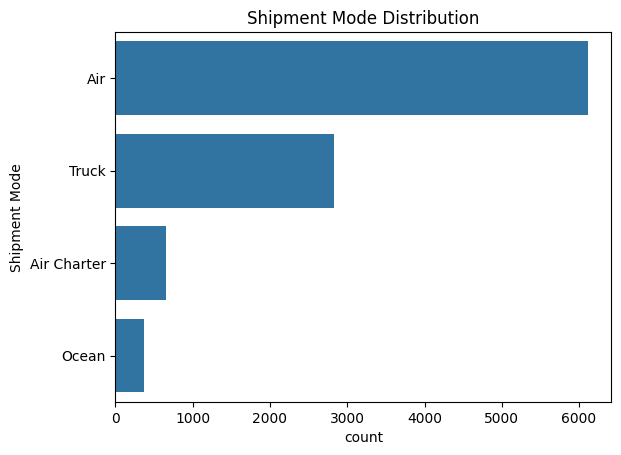

In [ ]:
sns.countplot(y='Shipment Mode', data=df)
plt.title('Shipment Mode Distribution')
plt.show()

In [ ]:
df.groupby('Shipment Mode')['Delivery Delay Days'].mean()

,Delivery Delay Days
Shipment Mode,
Air,-3.763782
Air Charter,-19.036923
Ocean,5.870620
Truck,-9.921908


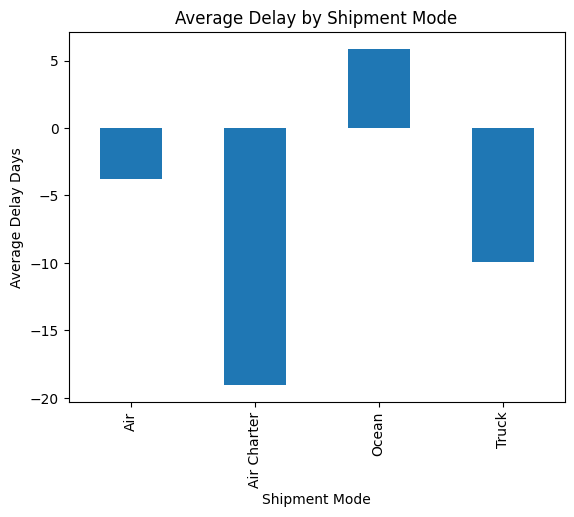

In [ ]:
df.groupby('Shipment Mode')['Delivery Delay Days'].mean().plot(kind='bar')

plt.title('Average Delay by Shipment Mode')
plt.ylabel('Average Delay Days')
plt.show()

In [ ]:
df['Country'].value_counts().head(10)

,count
Country,
South Africa,1406
Nigeria,1194
Côte d'Ivoire,1083
Uganda,779
Vietnam,688
Zambia,683
Haiti,655
Mozambique,631
Zimbabwe,538


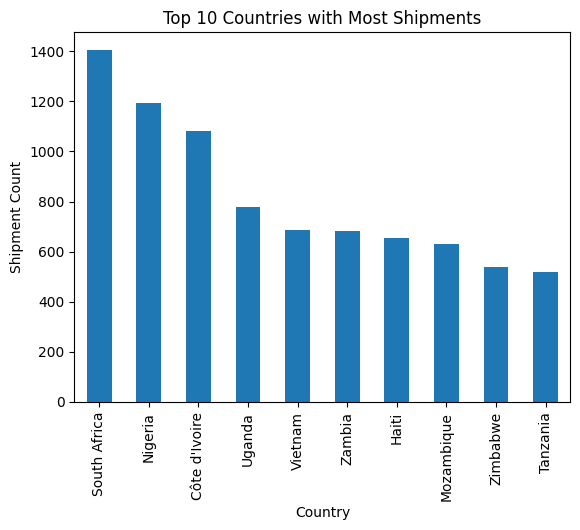

In [ ]:
df['Country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries with Most Shipments')
plt.ylabel('Shipment Count')
plt.show()

In [ ]:
df['Freight Cost (USD)'].describe()

,Freight Cost (USD)
count,10324
unique,6733
top,Freight Included in Commodity Cost
freq,1442


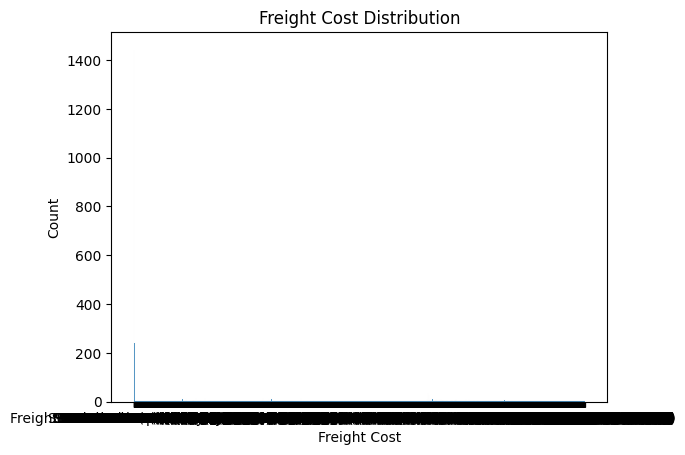

In [ ]:
sns.histplot(df['Freight Cost (USD)'],bins=30)

plt.title('Freight Cost Distribution')
plt.xlabel('Freight Cost')
plt.show()


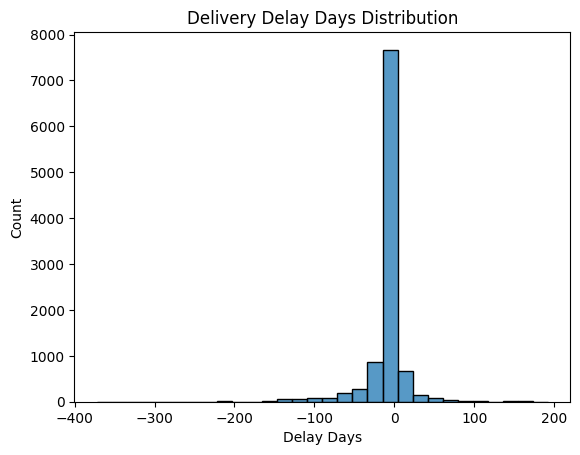

In [ ]:
sns.histplot(df['Delivery Delay Days'], bins=30)

plt.title('Delivery Delay Days Distribution')
plt.xlabel('Delay Days')
plt.show()

## Correlation Analysis

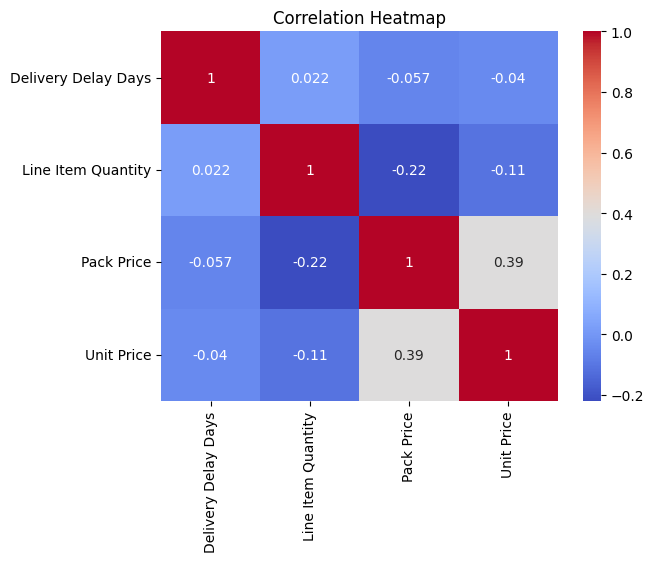

In [ ]:
numeric_cols = [
    'Delivery Delay Days',
    'Line Item Quantity',
    'Pack Price',
    'Unit Price'
]

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## Machine Learning Model Building

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Shipment Mode'] = le.fit_transform(df['Shipment Mode'])

df['Freight Cost (USD)'] = pd.to_numeric(
    df['Freight Cost (USD)'],
    errors='coerce'
)

df['Weight (Kilograms)'] = pd.to_numeric(
    df['Weight (Kilograms)'],
    errors='coerce'
)

df = df.dropna()

In [ ]:
features =[
    'Shipment Mode',
    'Freight Cost (USD)',
    'Weight (Kilograms)',
    'Line Item Quantity',
    'Pack Price'

]
x = df[features]

y = df['Delivery Status']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
y_pred = model.predict(x_test)

print(y_pred[:10])

['On Time' 'On Time' 'On Time' 'On Time' 'On Time' 'On Time' 'On Time'
 'On Time' 'On Time' 'On Time']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9313725490196079


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  0  21]
 [  0 285]]


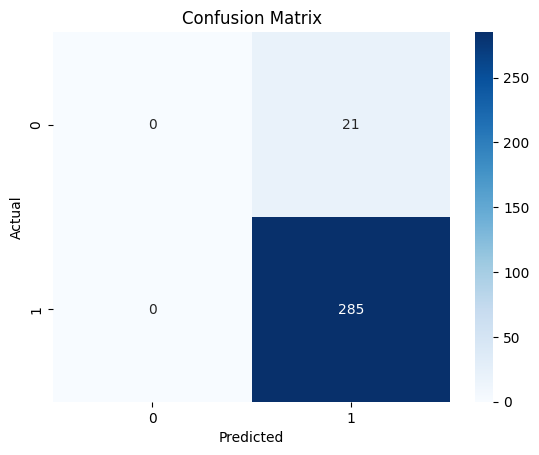

In [ ]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Delayed       0.00      0.00      0.00        21
     On Time       0.93      1.00      0.96       285

    accuracy                           0.93       306
   macro avg       0.47      0.50      0.48       306
weighted avg       0.87      0.93      0.90       306



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Key Insights

- Shipment mode impacts delivery delays.
- Freight cost and shipment weight influence logistics performance.
- Predictive analytics helps identify shipment delay patterns.
- Machine learning can improve logistics efficiency and operational planning.

## Recommendations

- Monitor high-risk shipment modes.
- Optimize freight allocation strategies.
- Improve shipment scheduling and route planning.
- Use predictive models before shipment dispatch.

## Conclusion

This project analyzed FedEx shipment logistics data and built a machine learning model to predict shipment delays. Using data analytics and machine learning techniques, the project identified operational patterns and improved understanding of logistics performance.